# <font color='blue'>Proyecto Activos Financieros</font>
### <font color='red'>17 de octubre de 2025</font>
### Andrés Padrón Quintana 
### <font color='green'>Curso : DATA SCIENCE AND MACHINE LEARNING APPLIED TO FINANCIAL MARKETS </font>

### 1. Descarga de datos históricos

Usaremos los tickers de Costco y Walmart

![Mi figura](costco.png)

In [17]:
# Importamos las librerías necesarias

import time
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

# Definimos los parámetros principales
TICKERS   = ["COST", "WMT"]   
N_DIAS    = 100               # Días que queremos para análisis
TRADING_DAYS = 252            # Esto es lo que se poner normalmente quitando fines de semana y días feriados
RF_ANNUAL = 0.00              # tasa libre de riesgo anual para Sharpe


In [18]:
# Descargamos los precios de los tickers para 100 días

def descarga_y_limpia(ticker: str, n_obs: int = 100) -> pd.DataFrame:
    """
    Descargamos ~8 meses de datos diarios con ajuste automático, limpiamos columnas y esto nos
    devuelve hasta n_obs filas.
    """
    last_exc = None
    for _ in range(3):  # reintentos por intermitencias de Yahoo
        try:
            hist = yf.Ticker(ticker).history(period="8mo", interval="1d", auto_adjust=True)
            if isinstance(hist, pd.DataFrame) and not hist.empty:
                cols_map = {"Open":"apertura", "High":"maximo", "Low":"minimo",
                            "Close":"cierre", "Volume":"volumen"}
                df = hist.rename(columns=cols_map).reset_index().rename(columns={"Date":"fecha"})
                df["precio_ajustado"] = df["cierre"]  # con auto_adjust=True ya está ajustado
                cols = ["fecha","apertura","cierre","maximo","minimo","volumen","precio_ajustado"]
                df = df[cols].copy()
                df.insert(1, "ticker", ticker)
                df["fecha"] = pd.to_datetime(df["fecha"])
                if df["fecha"].isna().any() or df["cierre"].isna().any():
                    df = df.dropna(subset=["fecha","cierre"])
                if len(df) >= n_obs:
                    df = df.tail(n_obs).copy()
                return df
            else:
                last_exc = ValueError(f"Yahoo devolvió vacío para {ticker}.")
        except Exception as e:
            last_exc = e
        time.sleep(1.0)
    raise RuntimeError(f"No se obtuvieron datos para {ticker}. Último error: {last_exc}")

dfs = []
for tk in TICKERS:
    dfi = descarga_y_limpia(tk, n_obs=N_DIAS)
    print(f"OK {tk}: {len(dfi)} filas, {dfi['fecha'].min().date()} → {dfi['fecha'].max().date()}")
    dfs.append(dfi)

precios_df = pd.concat(dfs, ignore_index=True)
display(precios_df.head())


OK COST: 100 filas, 2025-05-23 → 2025-10-15
OK WMT: 100 filas, 2025-05-23 → 2025-10-15


,fecha,ticker,apertura,cierre,maximo,minimo,volumen,precio_ajustado
0,2025-05-23 00:00:00-04:00,COST,1010.599894,1007.104736,1013.705577,1005.606812,1413900,1007.104736
1,2025-05-27 00:00:00-04:00,COST,1013.595779,1016.381897,1017.540326,1009.531402,1868200,1016.381897
2,2025-05-28 00:00:00-04:00,COST,1015.642906,1011.738342,1023.202440,1011.558599,1674700,1011.738342
3,2025-05-29 00:00:00-04:00,COST,1014.604383,1007.344421,1016.132235,1002.211518,2016700,1007.344421
4,2025-05-30 00:00:00-04:00,COST,1000.913308,1038.740967,1051.033873,1000.613735,5403800,1038.740967


- **Fuente:** Yahoo Finance vía `yfinance` (últimos ~100 días hábiles).
- **Estructura:** columnas `fecha`, `ticker`, `apertura`, `cierre`, `maximo`, `minimo`, `volumen`, `precio_ajustado`.
- **Ajustes:** se usó `auto_adjust=True`, por lo que `precio_ajustado` coincide con `cierre` (dividendos/splits ya incorporados).
- **Calidad de datos:**
  - Sin nulos en `fecha`/`cierre`.
  - Sin duplicados en la llave (`fecha`, `ticker`).
  - Las fechas muestran zona horaria del proveedor; se convertirá a **fecha** (sin hora) en el preprocesamiento.
- **Resultado:** se obtuvieron ~100 observaciones por activo para Walmart y Costco

### 2. Pipeline de preprocesamiento

In [20]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Calculamos los rendimientos log.

def add_log_price(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X["log_precio_ajustado"] = np.log(X["precio_ajustado"].astype(float))
    return X

AddLog = FunctionTransformer(
    add_log_price, feature_names_out="one-to-one", validate=False
)

# Eliminamos los Na's

class DropNA(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X):
        return X.dropna(subset=self.cols)

# Normalizamos dentro de cada activo

class GroupStandardScaler(BaseEstimator, TransformerMixin):
    """
    Aplica z-score por grupo (columna 'group_col') a 'num_cols':
        z = (x - media_grupo) / std_grupo
    """
    def __init__(self, group_col: str, num_cols: list[str]):
        self.group_col = group_col
        self.num_cols = num_cols
        self.params_ = {}

    def fit(self, X: pd.DataFrame, y=None):
        self.params_.clear()
        for g, df_g in X.groupby(self.group_col):
            self.params_[g] = {
                c: (df_g[c].mean(), df_g[c].std(ddof=0) if df_g[c].std(ddof=0) > 0 else 1.0)
                for c in self.num_cols
            }
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        for g, idx in X.groupby(self.group_col).groups.items():
            for c in self.num_cols:
                m, s = self.params_[g][c]
                X.loc[idx, c] = (X.loc[idx, c] - m) / s
        return X

num_cols = ["apertura","cierre","maximo","minimo","volumen","precio_ajustado"]
num_cols_with_log = num_cols + ["log_precio_ajustado"]

preprocess_pipe_by_ticker = Pipeline(steps=[
    ("add_log", AddLog),                                      # (i) log del precio ajustado
    ("drop_na", DropNA(cols=num_cols_with_log)),              # (ii) eliminar nulos
    ("group_scale", GroupStandardScaler("ticker", num_cols_with_log)),  # (iii) z-score por ticker
])

# Volvemos a armar e DataFrame

df_in = precios_df.copy()

# Para que 'fecha' y 'ticker' queden alineados con lo que sobrevive al drop_na:
df_after_addlog = preprocess_pipe_by_ticker.named_steps["add_log"].transform(df_in)
idx_valid = preprocess_pipe_by_ticker.named_steps["drop_na"].transform(df_after_addlog).index

df_out = preprocess_pipe_by_ticker.fit_transform(df_in)
# df_out ya contiene las columnas originales + transformadas. Nos quedamos con lo necesario:
precios_norm = df_out.loc[idx_valid, ["fecha","ticker"] + num_cols_with_log].reset_index(drop=True)

# Verificamos

print("Vista (precios normalizados por ticker + log):")
display(precios_norm.head(8))

print("\nResumen por ticker (esperado: media≈0, std≈1):")
display(
    precios_norm.groupby("ticker")[num_cols_with_log]
    .agg(["mean","std"])
    .round(3)
)


Vista (precios normalizados por ticker + log):


,fecha,ticker,apertura,cierre,maximo,minimo,volumen,precio_ajustado,log_precio_ajustado
0,2025-05-23 00:00:00-04:00,COST,1.387068,1.304214,1.244095,1.536760,-1.132527,1.304214,1.303122
1,2025-05-27 00:00:00-04:00,COST,1.482165,1.600763,1.362415,1.666368,-0.521566,1.600763,1.588470
2,2025-05-28 00:00:00-04:00,COST,1.547146,1.452329,1.537118,1.733315,-0.781793,1.452329,1.445970
3,2025-05-29 00:00:00-04:00,COST,1.514181,1.311876,1.318969,1.424632,-0.321857,1.311876,1.310527
4,2025-05-30 00:00:00-04:00,COST,1.079590,2.315480,2.395846,1.371866,4.233253,2.315480,2.265630
5,2025-06-02 00:00:00-04:00,COST,2.092999,2.847604,2.642650,2.436094,-0.145280,2.847604,2.760391
6,2025-06-03 00:00:00-04:00,COST,2.723168,2.807382,2.845390,2.732573,-0.353864,2.807382,2.723266
7,2025-06-04 00:00:00-04:00,COST,2.750114,2.682892,2.560383,2.934077,-1.121499,2.682892,2.608082



Resumen por ticker (esperado: media≈0, std≈1):


apertura        cierre        maximo        minimo        volumen        precio_ajustado        log_precio_ajustado       
           mean    std   mean    std   mean    std   mean    std    mean    std            mean    std                mean    std
ticker                                                                                                                           
COST        0.0  1.005    0.0  1.005    0.0  1.005    0.0  1.005    -0.0  1.005             0.0  1.005                -0.0  1.005
WMT        -0.0  1.005   -0.0  1.005    0.0  1.005    0.0  1.005    -0.0  1.005            -0.0  1.005                -0.0  1.005

Se implementó un pipeline que:
1) Crea `log_precio_ajustado = ln(precio_ajustado)`,
2) Elimina nulos en columnas numéricas, y
3) **normaliza por activo (z-score dentro de cada ticker)** las columnas:
   `apertura`, `cierre`, `maximo`, `minimo`, `volumen`, `precio_ajustado`, `log_precio_ajustado`.

**Verificación:** el resumen por ticker muestra medias ≈ 0 y desviaciones estándar ≈ 1 en todas las variables.
La pequeña desviación (~1.005) proviene de la diferencia entre varianza poblacional (escalado) y muestral, se podría mejorar y forzar para que de 1 exacto en la varianza.


### 3. Web Scraping del perfil de los activos

In [24]:
import requests, pandas as pd, numpy as np

TICKERS = ["COST", "WMT"] 

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 "
                  "KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.9",
    "Connection": "keep-alive",
}

Q2 = "https://query2.finance.yahoo.com/v10/finance/quoteSummary/{tk}?modules=assetProfile,price,quoteType"
Q1 = "https://query1.finance.yahoo.com/v10/finance/quoteSummary/{tk}?modules=assetProfile,price,quoteType"

def _parse_profile(block, tk):
    """Extraemos los campos requeridos de un bloque quoteSummary."""
    asset = block.get("assetProfile", {}) or {}
    price = block.get("price", {}) or {}
    qtype = block.get("quoteType", {}) or {}

    long_name = (
        price.get("longName")
        or qtype.get("longName")
        or qtype.get("shortName")
        or tk
    )
    addr_parts = [
        asset.get("address1"), asset.get("address2"), asset.get("address3"),
        asset.get("city"), asset.get("state"), asset.get("zip"), asset.get("country")
    ]
    direccion = ", ".join([str(x).strip() for x in addr_parts if x])

    return {
        "ticker": tk,
        "nombre_completo": long_name or "",
        "descripcion_general": asset.get("longBusinessSummary", "") or "",
        "direccion_fisica": direccion,
        "pagina_web": asset.get("website", "") or "",
        "sector": asset.get("sector", "") or "",
    }

def _try_query(session, url):
    r = session.get(url, headers=HEADERS, timeout=20)
    r.raise_for_status()
    data = r.json()
    res = data.get("quoteSummary", {}).get("result", [])
    return res[0] if res else None

def fetch_profile(tk: str) -> dict:
    with requests.Session() as s:
        # 1) Aplicamos query2
        try:
            block = _try_query(s, Q2.format(tk=tk))
            if block: 
                return _parse_profile(block, tk)
        except Exception:
            pass
        # 2) Ahora query1
        try:
            block = _try_query(s, Q1.format(tk=tk))
            if block:
                return _parse_profile(block, tk)
        except Exception:
            pass
    # 3) depués fallback: yfinance.get_info()
    try:
        import yfinance as yf
        info = yf.Ticker(tk).get_info()  
        addr_parts = [
            info.get("address1"), info.get("address2"), info.get("address3"),
            info.get("city"), info.get("state"), info.get("zip"), info.get("country")
        ]
        direccion = ", ".join([str(x).strip() for x in addr_parts if x])
        long_name = info.get("longName") or info.get("shortName") or tk
        return {
            "ticker": tk,
            "nombre_completo": long_name or "",
            "descripcion_general": info.get("longBusinessSummary", "") or "",
            "direccion_fisica": direccion,
            "pagina_web": info.get("website", "") or "",
            "sector": info.get("sector", "") or "",
        }
    except Exception as e:
        
        return {
            "ticker": tk,
            "nombre_completo": tk,
            "descripcion_general": "",
            "direccion_fisica": "",
            "pagina_web": "",
            "sector": "",
        }

rows = []
for tk in TICKERS:
    prof = fetch_profile(tk)
    rows.append(prof)
    print(f"Perfil {tk}: "
          f"{'OK' if any(prof.values()) else 'VACÍO'} | "
          f"Nombre='{prof['nombre_completo']}' | Sector='{prof['sector']}'")

perfil_df = pd.DataFrame(rows)
display(perfil_df)

# Limpiamos
perfil_df = perfil_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Guardamos en un archivo
perfil_df.to_csv("perfiles_yahoo.csv", index=False)
print("Archivo guardado: perfiles_yahoo.csv")


Perfil COST: OK | Nombre='Costco Wholesale Corporation' | Sector='Consumer Defensive'
Perfil WMT: OK | Nombre='Walmart Inc.' | Sector='Consumer Defensive'


,ticker,nombre_completo,descripcion_general,direccion_fisica,pagina_web,sector
0,COST,Costco Wholesale Corporation,"Costco Wholesale Corporation, together with it...","999 Lake Drive, Issaquah, WA, 98027, United St...",https://www.costco.com,Consumer Defensive
1,WMT,Walmart Inc.,Walmart Inc. engages in the operation of retai...,"702 South West 8th Street, Bentonville, AR, 72...",https://corporate.walmart.com,Consumer Defensive


Archivo guardado: perfiles_yahoo.csv


### 4. Modelado de base de datos y almacenamiento

In [42]:
from sqlalchemy import create_engine, text

# Nos conectamos con nuestras credenciales

MYSQL_USER = "root"
MYSQL_PASS = "Fergateodio7"
MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306 
DB_NAME    = "finanzas_db"

# Creamos la base
engine_root = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASS}@{MYSQL_HOST}:{MYSQL_PORT}/?charset=utf8mb4",
    pool_pre_ping=True, isolation_level="AUTOCOMMIT"
)
with engine_root.connect() as con:
    con.execute(text(
        f"CREATE DATABASE IF NOT EXISTS `{DB_NAME}` "
        "DEFAULT CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci;"
    ))
    print(f"Base '{DB_NAME}' lista.")

# Establecemos conexión a la base de trabajo
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASS}@{MYSQL_HOST}:{MYSQL_PORT}/{DB_NAME}?charset=utf8mb4",
    pool_pre_ping=True
)
print("Conectado a MySQL.")


Base 'finanzas_db' lista.
Conectado a MySQL.


In [43]:
from sqlalchemy.orm import declarative_base, relationship
from sqlalchemy import (
    Column, Integer, String, Float, Date, ForeignKey, UniqueConstraint, Text
)

Base = declarative_base()

# Definimos la clase Empresa
class Empresa(Base):
    __tablename__ = "Empresas"
    __table_args__ = {"mysql_engine": "InnoDB", "mysql_charset": "utf8mb4"}

    id   = Column(Integer, primary_key=True, autoincrement=True)           # PK numérico
    ticker = Column(String(12), unique=True, nullable=False, index=True)   # UNIQUE para mapear
    nombre_completo     = Column(String(255), nullable=False)
    descripcion_general = Column(Text, nullable=True)
    direccion_fisica    = Column(String(512), nullable=True)
    pagina_web          = Column(String(255), nullable=True)
    sector              = Column(String(128), nullable=True)

    precios = relationship("Precio", back_populates="empresa", cascade="all, delete-orphan")

# Definimos la clase Precio
class Precio(Base):
    __tablename__ = "Precios"
    __table_args__ = (
        UniqueConstraint("empresa_id", "fecha", name="uq_empresa_fecha"),  # unicidad por empresa y fecha
        {"mysql_engine": "InnoDB", "mysql_charset": "utf8mb4"},
    )

    id   = Column(Integer, primary_key=True, autoincrement=True)           # PK numérico
    empresa_id = Column(Integer, ForeignKey("Empresas.id", ondelete="CASCADE"), nullable=False, index=True)
    fecha  = Column(Date,  nullable=False, index=True)
    precio_apertura = Column(Float, nullable=False)
    precio_cierre   = Column(Float, nullable=False)

    empresa = relationship("Empresa", back_populates="precios")

Base.metadata.create_all(engine)
print("Esquema creado/actualizado (Empresas, Precios).")

Esquema creado/actualizado (Empresas, Precios).


In [44]:
import pandas as pd
from sqlalchemy import text

# EMPRESAS 
emp = perfil_df.copy()
emp = emp[["ticker","nombre_completo","descripcion_general","direccion_fisica","pagina_web","sector"]].drop_duplicates("ticker")
emp["ticker"] = emp["ticker"].astype(str)
emp["nombre_completo"] = emp["nombre_completo"].fillna("")

# UPSERT por ticker (Para hacer un nuevo registro o actualizarlo)
sql_emp = text("""
INSERT INTO Empresas (ticker, nombre_completo, descripcion_general, direccion_fisica, pagina_web, sector)
VALUES (:ticker, :nombre_completo, :descripcion_general, :direccion_fisica, :pagina_web, :sector)
ON DUPLICATE KEY UPDATE
  nombre_completo=VALUES(nombre_completo),
  descripcion_general=VALUES(descripcion_general),
  direccion_fisica=VALUES(direccion_fisica),
  pagina_web=VALUES(pagina_web),
  sector=VALUES(sector);
""")
with engine.begin() as con:
    con.execute(sql_emp, emp.to_dict(orient="records"))

# Mapa ticker -> empresa_id
with engine.connect() as con:
    map_df = pd.read_sql(text("SELECT id AS empresa_id, ticker FROM Empresas;"), con)
map_ticker_id = dict(zip(map_df["ticker"], map_df["empresa_id"]))

# PRECIOS 
px = precios_df.copy()
px["fecha"] = pd.to_datetime(px["fecha"]).dt.date
px = px.rename(columns={"apertura":"precio_apertura", "cierre":"precio_cierre"})
px = px[["fecha","ticker","precio_apertura","precio_cierre"]].dropna()
px = px[px["ticker"].isin(map_ticker_id.keys())].copy()
px["empresa_id"] = px["ticker"].map(map_ticker_id)
px = px.drop(columns=["ticker"]).drop_duplicates(subset=["empresa_id","fecha"])

# Valida mínimos de integridad (no nulos en campos clave)
assert not px[["empresa_id","fecha","precio_apertura","precio_cierre"]].isna().any().any(), "Hay nulos en Precios"

# UPSERT (Para hacer un nuevo registro o actualizarlo)
sql_px = text("""
INSERT INTO Precios (empresa_id, fecha, precio_apertura, precio_cierre)
VALUES (:empresa_id, :fecha, :precio_apertura, :precio_cierre)
ON DUPLICATE KEY UPDATE
  precio_apertura=VALUES(precio_apertura),
  precio_cierre=VALUES(precio_cierre);
""")
with engine.begin() as con:
    con.execute(sql_px, px.to_dict(orient="records"))

print("Inserciones completadas (Empresas y Precios).")


Inserciones completadas (Empresas y Precios).


In [45]:
from sqlalchemy import text

with engine.connect() as con:
    n_emp = con.execute(text("SELECT COUNT(*) FROM Empresas;")).scalar_one()
    n_px  = con.execute(text("SELECT COUNT(*) FROM Precios;")).scalar_one()
    print(f"Empresas: {n_emp} | Precios: {n_px}")

    q = """
    SELECT E.id AS empresa_id, E.ticker, E.nombre_completo, P.fecha, P.precio_apertura, P.precio_cierre
    FROM Precios P
    JOIN Empresas E ON E.id = P.empresa_id
    ORDER BY E.ticker, P.fecha DESC
    LIMIT 10;
    """
    df_check = pd.read_sql(text(q), con)
    display(df_check)


Empresas: 2 | Precios: 200


,empresa_id,ticker,nombre_completo,fecha,precio_apertura,precio_cierre
0,1,COST,Costco Wholesale Corporation,2025-10-15,946.00,954.99
1,1,COST,Costco Wholesale Corporation,2025-10-14,940.26,946.51
2,1,COST,Costco Wholesale Corporation,2025-10-13,929.00,935.56
3,1,COST,Costco Wholesale Corporation,2025-10-10,944.42,930.01
4,1,COST,Costco Wholesale Corporation,2025-10-09,932.31,942.89
5,1,COST,Costco Wholesale Corporation,2025-10-08,912.54,914.80
6,1,COST,Costco Wholesale Corporation,2025-10-07,908.73,914.80
7,1,COST,Costco Wholesale Corporation,2025-10-06,915.50,910.94
8,1,COST,Costco Wholesale Corporation,2025-10-03,915.59,915.38
9,1,COST,Costco Wholesale Corporation,2025-10-02,912.56,916.77


**Tablas diseñadas:**
- **Empresas**: `id` (PK autoincrement), `ticker` (UNIQUE, NOT NULL), `nombre_completo` (NOT NULL), `descripcion_general`, `direccion_fisica`, `pagina_web`, `sector`.
- **Precios**: `id` (PK autoincrement), `fecha` (DATE, NOT NULL), `precio_apertura` (NOT NULL), `precio_cierre` (NOT NULL), `empresa_id` (FK → Empresas.id, NOT NULL), `UNIQUE (empresa_id, fecha)`.

**Carga:** perfiles (API/scraping) → *Empresas* con UPSERT por `ticker`; precios históricos → *Precios* mapeando `ticker → empresa_id`, con UPSERT por `(empresa_id, fecha)`.

**Integridad aplicada:** PK/FK, unicidad, NOT NULL en campos clave y tipos correctos.

**Validación:** `Empresas = 2`, `Precios = 200`. Un JOIN muestra las últimas observaciones de cada empresa.


### 5. Consultas de verificación

In [46]:
from sqlalchemy import text
import pandas as pd

# Hacemos la consulta de todos los precios de un activo
TICKER = "COST"  # <-- cambiamios a 'WMT' si queremos de Walmart
q1 = """
SELECT e.ticker, e.nombre_completo, p.fecha, p.precio_apertura, p.precio_cierre
FROM Precios p
JOIN Empresas e ON e.id = p.empresa_id
WHERE e.ticker = :tk
ORDER BY p.fecha;
"""

# Hacemos la consulta del listado empresas y su sector
q2 = """
SELECT ticker, nombre_completo, sector
FROM Empresas
ORDER BY ticker;
"""

# Hacemos la consulta de los máximos y mínimos por empresa (con fechas)
q3 = """
WITH rangos AS (
  SELECT p.empresa_id,
         MIN(p.precio_cierre) AS min_cierre,
         MAX(p.precio_cierre) AS max_cierre
  FROM Precios p
  GROUP BY p.empresa_id
)
SELECT e.ticker,
       e.nombre_completo,
       r.min_cierre,
       (SELECT fecha FROM Precios
         WHERE empresa_id = e.id AND precio_cierre = r.min_cierre
         ORDER BY fecha LIMIT 1) AS fecha_min,
       r.max_cierre,
       (SELECT fecha FROM Precios
         WHERE empresa_id = e.id AND precio_cierre = r.max_cierre
         ORDER BY fecha LIMIT 1) AS fecha_max
FROM rangos r
JOIN Empresas e ON e.id = r.empresa_id
ORDER BY e.ticker;
"""

with engine.connect() as con:
    df1 = pd.read_sql(text(q1), con, params={"tk": TICKER})
    df2 = pd.read_sql(text(q2), con)
    df3 = pd.read_sql(text(q3), con)

print(f"(1) Precios de {TICKER}:")
display(df1.head(10))

print("\n(2) Empresas y sector:")
display(df2)

print("\n(3) Máximos y mínimos por empresa:")
display(df3)


(1) Precios de COST:


,ticker,nombre_completo,fecha,precio_apertura,precio_cierre
0,COST,Costco Wholesale Corporation,2025-05-23,1010.60,1007.10
1,COST,Costco Wholesale Corporation,2025-05-27,1013.60,1016.38
2,COST,Costco Wholesale Corporation,2025-05-28,1015.64,1011.74
3,COST,Costco Wholesale Corporation,2025-05-29,1014.60,1007.34
4,COST,Costco Wholesale Corporation,2025-05-30,1000.91,1038.74
5,COST,Costco Wholesale Corporation,2025-06-02,1032.84,1055.39
6,COST,Costco Wholesale Corporation,2025-06-03,1052.69,1054.13
7,COST,Costco Wholesale Corporation,2025-06-04,1053.54,1050.23
8,COST,Costco Wholesale Corporation,2025-06-05,1048.55,1009.41
9,COST,Costco Wholesale Corporation,2025-06-06,1019.22,1013.54



(2) Empresas y sector:


,ticker,nombre_completo,sector
0,COST,Costco Wholesale Corporation,Consumer Defensive
1,WMT,Walmart Inc.,Consumer Defensive



(3) Máximos y mínimos por empresa:


,ticker,nombre_completo,min_cierre,fecha_min,max_cierre,fecha_max
0,COST,Costco Wholesale Corporation,910.9400,2025-10-06,1055.39,2025-06-02
1,WMT,Walmart Inc.,94.0304,2025-06-17,109.03,2025-10-15


### 6. Análisis estadístico y visualización

In [47]:
import pandas as pd
from sqlalchemy import text

# Traemos datos desde MySQL

q = """
SELECT e.ticker, p.fecha, p.precio_apertura, p.precio_cierre
FROM Precios p
JOIN Empresas e ON e.id = p.empresa_id
ORDER BY e.ticker, p.fecha;
"""
with engine.connect() as con:
    df_px = pd.read_sql(text(q), con)

df_px["fecha"] = pd.to_datetime(df_px["fecha"])
df_px.head()


,ticker,fecha,precio_apertura,precio_cierre
0,COST,2025-05-23,1010.60,1007.10
1,COST,2025-05-27,1013.60,1016.38
2,COST,2025-05-28,1015.64,1011.74
3,COST,2025-05-29,1014.60,1007.34
4,COST,2025-05-30,1000.91,1038.74


In [48]:
import numpy as np

# Hacemos los resumenes estadísticos

def resumen_precio(df: pd.DataFrame, col: str) -> pd.DataFrame:
    g = df.groupby("ticker")[col]
    out = pd.DataFrame({
        "n": g.count(),
        "media": g.mean(),
        "std": g.std(ddof=1),
        "min": g.min(),
        "max": g.max()
    }).round(4)
    out["columna"] = col
    cols = ["columna","n","media","std","min","max"]
    return out[cols]

res_ap = resumen_precio(df_px, "precio_apertura")
res_ci = resumen_precio(df_px, "precio_cierre")
resumen = pd.concat([res_ap, res_ci]).reset_index().rename(columns={"index":"ticker"})

print("Resumen estadístico (por ticker y columna):")
display(resumen)

print("\nOrdenado por std de precio_cierre:")
display(resumen[resumen["columna"]=="precio_cierre"].sort_values("std", ascending=False))


Resumen estadístico (por ticker y columna):


,ticker,columna,n,media,std,min,max
0,COST,precio_apertura,100,966.9026,31.6621,908.7300,1053.54
1,WMT,precio_apertura,100,99.0472,3.1571,93.7311,107.32
2,COST,precio_cierre,100,966.3039,31.4412,910.9400,1055.39
3,WMT,precio_cierre,100,99.2004,3.2955,94.0304,109.03



Ordenado por std de precio_cierre:


,ticker,columna,n,media,std,min,max
2,COST,precio_cierre,100,966.3039,31.4412,910.9400,1055.39
3,WMT,precio_cierre,100,99.2004,3.2955,94.0304,109.03


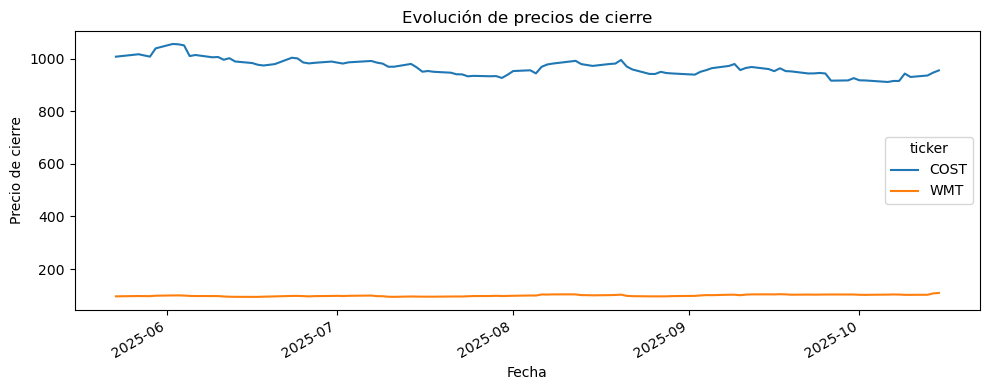

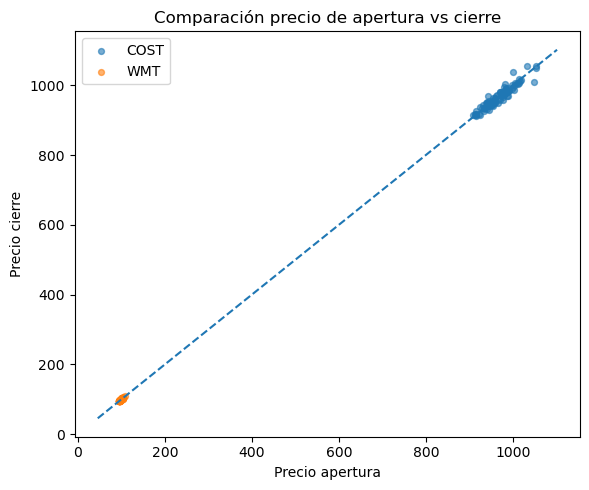

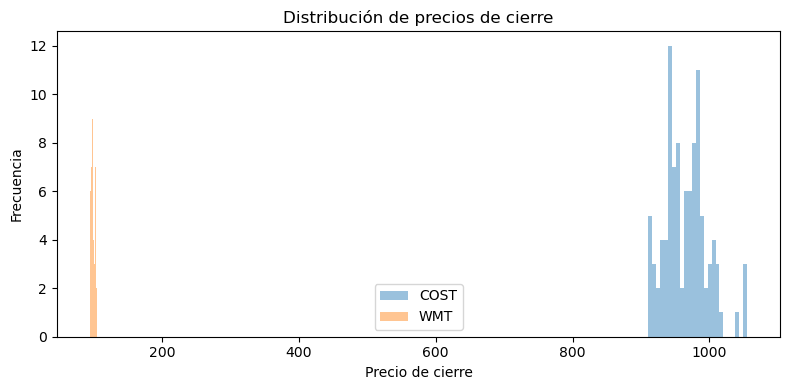

In [49]:
import matplotlib.pyplot as plt

# Hacemos las visualizaciones
# Evolución de precios de cierre en el tiempo
wide_close = (
    df_px.pivot(index="fecha", columns="ticker", values="precio_cierre")
    .sort_index()
    .dropna()
)
plt.figure(figsize=(10,4))
wide_close.plot(ax=plt.gca(), title="Evolución de precios de cierre")
plt.xlabel("Fecha"); plt.ylabel("Precio de cierre")
plt.tight_layout(); plt.show()

# Comparación apertura vs cierre
fig, ax = plt.subplots(figsize=(6,5))
for tk, sub in df_px.groupby("ticker"):
    ax.scatter(sub["precio_apertura"], sub["precio_cierre"], s=18, alpha=0.6, label=tk)
xmin, xmax = ax.get_xlim()
ax.plot([xmin, xmax], [xmin, xmax], linestyle="--")  # línea y=x
ax.set_title("Comparación precio de apertura vs cierre")
ax.set_xlabel("Precio apertura"); ax.set_ylabel("Precio cierre")
ax.legend(); plt.tight_layout(); plt.show()

# Distribución de precios de cierre
fig, ax = plt.subplots(figsize=(8,4))
bins = 25
for tk, sub in df_px.groupby("ticker"):
    ax.hist(sub["precio_cierre"], bins=bins, alpha=0.45, label=tk)
ax.set_title("Distribución de precios de cierre")
ax.set_xlabel("Precio de cierre"); ax.set_ylabel("Frecuencia")
ax.legend(); plt.tight_layout(); plt.show()


- **Evolución temporal:** COST mantiene niveles de precio muy superiores a WMT durante todo el periodo. Se observan oscilaciones moderadas y episodios de retroceso/recuperación, especialmente en COST a finales del intervalo.
- **Apertura vs. cierre:** Los puntos caen muy cerca de la línea `y = x` para ambos tickers → fuerte alineación intradía entre apertura y cierre (pequeños cambios diarios).
- **Distribución de precios:** Las distribuciones son unimodales. COST presenta un rango de cierre amplio (≈ 900–1,050), mientras que WMT se concentra alrededor de 95–115. La dispersión de COST es mayor en términos absolutos.
- La media y el rango de COST superan a WMT; la desviación también es mayor en términos absolutos (acorde al rango observado). Esto sugiere que, en niveles de precio, COST es más “volátil” que WMT.
